# CONCH 原理·玩具版：教会模型"看图识字"，然后用文字分类

> 这个 notebook 只回答一个问题：**模型从来没见过"类别标签"，为什么能用一句文字描述（比如"恶性肿瘤组织"）直接给图片分类？**
>
> 📚 玩具版系列第三篇。[CLAM 篇](CLAM_原理_玩具版.ipynb) 讲弱监督分类，[UNI2 篇](UNI2_原理_玩具版.ipynb) 讲无标签学特征；
> 本篇讲**第三种监督信号：图文配对**。姊妹篇：[TITAN](TITAN_原理_玩具版.ipynb)（切片级基础模型）。

**背景**：CONCH（CONtrastive learning from Captions for Histopathology，Nature Medicine 2024）的训练数据不是"这张图=癌"，
而是 **117 万对"病理图片 + 它的图注文字"**（PubMed Central 开放获取论文的配图说明 + 内部整理的教学资料）。学完之后的超能力：**零样本分类**——你写一句"异型增生上皮"，
它就能给从没见过的图片打分，不需要为每个新任务重新训练（前提是这个概念在预训练的图文里出现过）。

**你将看到**：
1. 造一个 12 个词的玩具世界：图片是 4 维向量，"图注"是词频向量
2. 训练图文对齐（核心又是老朋友 softmax）
3. 两个超能力演示：**用文字 prompt 零样本分类** + **以文搜图**

## 1. 问题设定：一个 12 个词的玩具世界

- **图片**：4 维向量。肿瘤 patch 围绕原型 (2,2,2,2) 抖动，正常 patch 围绕 (0,0,0,0) 抖动（有重叠，单看不是总能分对）
- **图注**：玩具词典只有 12 个词。肿瘤的图注偏爱"异型性、核分裂象、恶性、癌、浸润"；正常的偏爱"正常、腺体、间质、良性、炎症"；
  "组织、细胞"两边都用（干扰词）。每条图注随机取 3 个词，表示成 12 维词频向量

关键设定：训练数据是 **(图片, 图注) 配对**，就像教科书里"图 3：肺腺癌，可见异型腺体"这样的配图说明。
**从头到尾没有"类别"这个概念**——没有 0/1 标签，只有"这张图配这段话"。

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
torch.manual_seed(42); rng = np.random.default_rng(42)

# ============ 玩具词典 ============
VOCAB = ['异型性', '核分裂象', '恶性', '癌', '浸润',      # 0-4: 肿瘤词
         '正常', '腺体', '间质', '良性', '炎症',           # 5-9: 正常词
         '组织', '细胞']                                   # 10-11: 共用干扰词
TUMOR_WORDS, NORMAL_WORDS, SHARED = list(range(0, 5)), list(range(5, 10)), [10, 11]

def make_caption(is_tumor):
    """造一条 3 个词的图注：2 个类别词 + 1 个共用词 → 12 维词频向量。"""
    words = list(rng.choice(TUMOR_WORDS if is_tumor else NORMAL_WORDS, 2, replace=False))
    words += [rng.choice(SHARED)]
    vec = np.zeros(len(VOCAB), dtype=np.float32)
    for w in words: vec[w] += 1
    return vec, '、'.join(VOCAB[w] for w in words)

def make_image(is_tumor):
    """造一张 4 维假 patch。"""
    return (rng.normal(2, 0.7, 4) if is_tumor else rng.normal(0, 0.7, 4)).astype(np.float32)

# ============ 造 1200 对训练数据 + 400 张测试图片 ============
N_TRAIN, N_TEST = 1200, 400
imgs, caps = [], []
for i in range(N_TRAIN):
    t = i % 2 == 0
    imgs.append(make_image(t)); caps.append(make_caption(t)[0])
test_imgs = np.stack([make_image(i % 2 == 0) for i in range(N_TEST)])   # 交替：200 肿瘤 200 正常
test_labels = np.array([i % 2 == 0 for i in range(N_TEST)])             # 只用于最后打分

imgs_t, caps_t = torch.from_numpy(np.stack(imgs)), torch.from_numpy(np.stack(caps))
print(f'训练图文对: {N_TRAIN} 对 | 测试图片: {N_TEST} 张')
print()
print('训练数据长这样（前 3 对）:')
for i in range(3):
    _, text = make_caption(i % 2 == 0)
    print(f'  图片 {np.round(imgs[i], 1)}  ↔  图注「{text}」')

训练图文对: 1200 对 | 测试图片: 400 张

训练数据长这样（前 3 对）:
  图片 [2.2 1.3 2.5 2.7]  ↔  图注「浸润、恶性、细胞」
  图片 [ 0.1 -0.2 -0.  -0.6]  ↔  图注「良性、腺体、组织」
  图片 [2.  2.8 2.3 1.4]  ↔  图注「浸润、恶性、细胞」


## 2. 训练：把图片和文字塞进同一个"语义空间"

结构简单到不像话：两个编码器各是一层线性变换，都输出 **2 维向量**（又是为了画给你看）。

训练目标（**对比损失**，和 UNI2 篇是同一个思想，只是这次配对的是图和文）：

```
一个 batch 里 1200 对 → 图片编码 1200 个向量，图注编码 1200 个向量
对图片 i：它的图注是"正样本"（要靠近），其余 1199 条图注是"负样本"（要远离）
→ 又是 1199 选 1 的分类题（softmax 第三次出场：给图选文、给文选图，两个方向都算）
```

学完之后的语义空间有个神奇的性质：**意思相近的东西，不管什么模态，都会聚在一起**——
肿瘤的图、肿瘤的词、描述肿瘤的句子，都住在同一个街区。

⚠️ 玩具里特别明显的一个问题：图片只携带"是不是肿瘤"的信息，同类图片配到哪条图注纯属随机（12 个词只能组出 40 种图注，大量重复）。
对每张图来说，600 条同类图注都一样"对"，可损失只认第 i 条，其余 599 条同类图注被当成负样本推开（叫作**假负样本**）。
所以下面的损失降不到 0：理论下限是 log(600)≈6.40（全猜 = log(1200)≈7.09），实际停在 6.42 左右，已经几乎到底。
真实数据里也有假负样本（不同论文的图注可能几乎相同），只是比例小得多。

In [2]:
class ConchToy(nn.Module):
    """玩具版 CONCH：图像编码器 + 文本编码器，都映射到 2 维共享语义空间。"""
    def __init__(self):
        super().__init__()
        self.img_enc = nn.Linear(4, 2)     # 真实 CONCH: ViT-B/16 图像编码器 → 512 维
        self.txt_enc = nn.Linear(12, 2)    # 真实 CONCH: 12 层 Transformer 文本编码器 → 512 维
    def forward(self, img, txt):
        zi = F.normalize(self.img_enc(img), dim=1)   # 归一化到单位圆上
        zt = F.normalize(self.txt_enc(txt), dim=1)
        return zi, zt

model = ConchToy()
opt = torch.optim.Adam(model.parameters(), lr=3e-3)
TAU = 0.1                                # 温度：越小越"较真"（又是 softmax 里的缩放）

for ep in range(600):
    zi, zt = model(imgs_t, caps_t)
    logits = zi @ zt.T / TAU             # 1200×1200: 每张图对每条图注的相似度
    gold = torch.arange(N_TRAIN)         # 第 i 张图的正确图注就是第 i 条
    loss = (F.cross_entropy(logits, gold) + F.cross_entropy(logits.T, gold)) / 2  # 图→文 + 文→图
    opt.zero_grad(); loss.backward(); opt.step()
    if ep % 150 == 149:
        top1 = logits.argmax(dim=1)                      # 每张图最匹配的图注编号
        # 逐字精确匹配没意义（12 个词只能组出有限条图注，大量重复），看"类别级"配对:
        # 选中的图注是否和图片同类（图注含肿瘤词=肿瘤类；图片编号偶数=肿瘤类）
        cap_is_tumor = torch.tensor([bool(caps_t[i][:5].sum() > 0) for i in range(N_TRAIN)])
        img_is_tumor = torch.tensor([i % 2 == 0 for i in range(N_TRAIN)])
        cls_acc = (cap_is_tumor[top1] == img_is_tumor).float().mean()
        print(f'epoch {ep+1:3d}: loss={loss.item():.3f}  类别级图文配对准确率={cls_acc:.1%}')

epoch 150: loss=6.529  类别级图文配对准确率=97.4%


epoch 300: loss=6.423  类别级图文配对准确率=99.7%


epoch 450: loss=6.416  类别级图文配对准确率=99.7%


epoch 600: loss=6.415  类别级图文配对准确率=99.8%


## 3. 先看语义空间长什么样

把测试图片和两个"文字 prompt"都放进同一个空间：圆点 = 图片（红 = 实际是肿瘤，蓝 = 实际是正常），五角星 = 文字。
如果训练成功，**文字应该落在对应类别的图片堆里**——这就是"看懂文字"的几何含义。

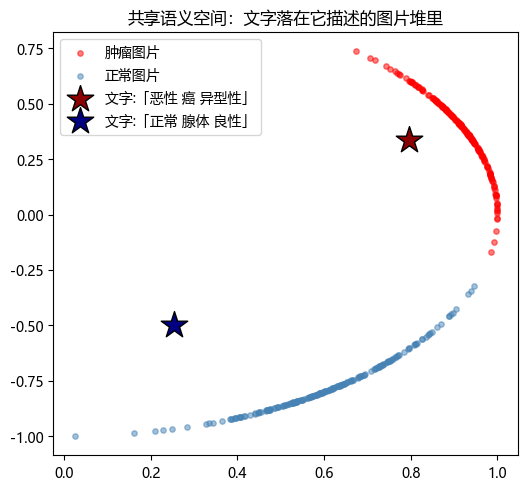

In [3]:
def encode_text(words):
    """把一句文字描述变成语义向量（词频 → 文本编码器）。"""
    vec = np.zeros(len(VOCAB), dtype=np.float32)
    for w in words: vec[VOCAB.index(w)] += 1
    with torch.no_grad():
        return model.txt_enc(torch.from_numpy(vec)).numpy()

prompt_tumor  = encode_text(['恶性', '癌', '异型性'])     # 一句"肿瘤描述"
prompt_normal = encode_text(['正常', '腺体', '良性'])     # 一句"正常描述"

with torch.no_grad():
    zi_test = F.normalize(model.img_enc(torch.from_numpy(test_imgs)), dim=1).numpy()

plt.figure(figsize=(6, 5.5))
plt.scatter(zi_test[test_labels, 0], zi_test[test_labels, 1], s=15, alpha=0.5, c='red', label='肿瘤图片')
plt.scatter(zi_test[~test_labels, 0], zi_test[~test_labels, 1], s=15, alpha=0.5, c='steelblue', label='正常图片')
plt.scatter(*prompt_tumor, marker='*', s=400, c='darkred', edgecolors='k', label='文字:「恶性 癌 异型性」', zorder=5)
plt.scatter(*prompt_normal, marker='*', s=400, c='navy', edgecolors='k', label='文字:「正常 腺体 良性」', zorder=5)
plt.legend(); plt.title('共享语义空间：文字落在它描述的图片堆里')
plt.show()

## 4. 超能力一：零样本分类（不用训练的分类器！）

给 400 张**从没见过的**新图片分类，方法朴素到可爱：
**每张图和两句文字描述各算一次相似度，像谁就归谁。**

注意：从训练到现在，模型没见过任何 0/1 类别标签——"肿瘤"这个概念是它从图文配对里自己悟出来的。
（说句公道话：玩具里图注是按类别造的，肿瘤图片配的就是肿瘤词，所以图注其实是一种**间接、带噪声的标签**。真实图注也一样，监督信号就藏在文字里。）
这就是 **zero-shot classification**：想分新的类别？写句话就行，不用收集数据、不用训练——前提是这个概念在预训练的图文里见过，没见过的概念写了也白写。

In [4]:
sim_t = zi_test @ prompt_tumor      # 每张图和"肿瘤描述"的相似度
sim_n = zi_test @ prompt_normal     # 每张图和"正常描述"的相似度
preds = sim_t > sim_n               # 像谁就归谁
acc = (preds == test_labels).mean()
print(f'零样本分类准确率: {acc:.1%}  (400 张没见过的图，只靠两句文字描述)')
print()
print('前 6 张图的实际判断过程:')
for i in range(6):
    truth = '肿瘤' if test_labels[i] else '正常'
    pred = '肿瘤' if preds[i] else '正常'
    mark = '✓' if preds[i] == test_labels[i] else '✗'
    print(f'  图 {i}: 与「恶性癌异型性」相似度 {sim_t[i]:+.2f} vs 与「正常腺体良性」{sim_n[i]:+.2f} → 判 {pred} (实际 {truth}) {mark}')

零样本分类准确率: 96.5%  (400 张没见过的图，只靠两句文字描述)

前 6 张图的实际判断过程:
  图 0: 与「恶性癌异型性」相似度 +0.85 vs 与「正常腺体良性」+0.14 → 判 肿瘤 (实际 肿瘤) ✓
  图 1: 与「恶性癌异型性」相似度 +0.14 vs 与「正常腺体良性」+0.56 → 判 正常 (实际 正常) ✓
  图 2: 与「恶性癌异型性」相似度 +0.84 vs 与「正常腺体良性」-0.10 → 判 肿瘤 (实际 肿瘤) ✓
  图 3: 与「恶性癌异型性」相似度 +0.36 vs 与「正常腺体良性」+0.52 → 判 正常 (实际 正常) ✓
  图 4: 与「恶性癌异型性」相似度 +0.86 vs 与「正常腺体良性」+0.02 → 判 肿瘤 (实际 肿瘤) ✓
  图 5: 与「恶性癌异型性」相似度 +0.36 vs 与「正常腺体良性」+0.53 → 判 正常 (实际 正常) ✓


## 5. 超能力二：以文搜图（跨模态检索）

反过来玩：写一句 "核分裂象、浸润、癌"，让模型从 400 张图里找出最符合的 8 张。数数有几张真的是肿瘤。
这在真实世界里的用法：**在海量病理图像块（patch / ROI）里搜索"像肺鳞癌的区域"**——不用提前做任何标注。
（CONCH 编码的是图像块；要按整张切片检索，还得把一张切片的 patch 汇总起来，这正是 TITAN 篇要讲的事。）

In [5]:
query = encode_text(['核分裂象', '浸润', '癌'])
sims = zi_test @ query
top8 = sims.argsort()[::-1][:8]          # 相似度最高的 8 张
hits = test_labels[top8].sum()
print(f'查询:「核分裂象、浸润、癌」')
print(f'最匹配的 8 张图: {sorted(int(i) for i in top8)}')
print(f'其中真肿瘤: {hits}/8')
print()
print('相似度分布: 肿瘤图 vs 正常图 (越分开越好)')
print(f'  肿瘤图平均相似度: {sims[test_labels].mean():+.3f}')
print(f'  正常图平均相似度: {sims[~test_labels].mean():+.3f}')

查询:「核分裂象、浸润、癌」
最匹配的 8 张图: [100, 110, 116, 162, 186, 204, 254, 332]
其中真肿瘤: 8/8

相似度分布: 肿瘤图 vs 正常图 (越分开越好)
  肿瘤图平均相似度: +0.639
  正常图平均相似度: +0.126


## 6. 诚实声明：玩具版 vs 真实 CONCH

| | 玩具版（本 notebook） | 真实 CONCH |
|---|---|---|
| 训练目标 | 只有对比学习（图↔文互找） | **CoCa = 对比学习 + 看图说话**（额外训练一个解码器根据图片生成文字描述，逼模型理解得更细） |
| 图像编码器 | Linear(4→2)，10 个参数（4×2 权重 + 2 偏置） | ViT-B/16（约 9000 万参数），先用 iBOT 在 1600 万个病理图像块（来自 21,442 张切片）上自监督预训练 |
| 文本编码器 | Linear(12→2)，26 个参数 | 12 层 Transformer（约 1.1 亿参数）。先在 55 万+份病理报告的诊断段落和 40 万+篇病理相关 PubMed 摘要上预训练一个 24 层语言模型，前 12 层初始化文本编码器、后 12 层初始化解码器 |
| "文字"是什么 | 12 词玩具词典的词频向量（词序无关） | 真实英文句子（先切成子词 token，词序有意义），如 "H&E stained section of lung adenocarcinoma" |
| 语义空间维度 | 2 维 | **512 维** |
| 训练数据 | 1200 对假数据 | **117 万+图文对**（PubMed Central 开放获取论文的配图说明 + 内部整理的教学资料，含 H&E / IHC / 特殊染色） |

**CONCH 在 CLAM 流水线里的两种用法**：
1. 当第 3 步的特征提取器（512 维，下游 `--embed_dim 512`）——它也是 TITAN 的 patch 编码器（实际用的是升级版 CONCH v1.5，768 维）
2. 直接做零样本分类 / 以文搜图 / 图文检索——不写一行训练代码就能出结果

> ⚖️ 诚实的简化：玩具版只演示 CoCa 的一半（对比对齐）；"看图说话"那一半（captioning 解码器）需要真正的序列生成，
> 玩具里放不下，但思想相同：让模型把视觉内容翻译成语言，理解就深了。
> 另注：为防止专有数据或受保护的健康信息（PHI）经由生成泄露，官方发布的 CONCH 权重去掉了解码器，所以拿不到"看图说话"功能。

## 7. 三句话小结

1. **图文配对也是一种监督**："这张图配这段话"里藏着丰富的语义，不需要人工打类别标签。
2. **对齐 = 把两个模态映射到同一空间**，训练目标还是老朋友 softmax：给图找对文、给文找对图。
3. **对齐之后，文字变成了"免费的分类器/搜索引擎"**：写句描述就能分类新图、检索全库——这就是零样本能力。

→ 下一篇 [TITAN_原理_玩具版.ipynb](TITAN_原理_玩具版.ipynb)：把一整张切片的几千个 patch 压缩成一个"切片级指纹"，能干什么？